Charlie Frank

# MAE 243 Final Project, Spring 2026

LLM model Claude Sonnet 4.6 was used in part to assist with model generation, specific AI additions to model for debugging purposes are pointed out. Some sections were generated using AI After providing representative code from notebooks and information on datasets to streamline and speed up the production process.

# Load Packages

In [46]:
# Uncomment to install on first run:
# import Pkg
# Pkg.add(["JuMP", "HiGHS", "DataFrames", "CSV", "Statistics", "Plots", "StatsPlots"])

using JuMP, HiGHS,Gurobi
using DataFrames, CSV
using Statistics
using Plots, StatsPlots

ENV["COLUMNS"] = 180

180

# Load Data 

wecc_2045_all_clean_expansion is used for this project. A description of the data is as follows:

This data set provides inputs for a capacity expansion planning study considering options for a 100% carbon-free electricity system across the U.S. portion of the Western Interconnection (Western Electricity Coordinating Council or WECC).

All inputs are generated by the open source [PowerGenome data platform](https://github.com/gschivley/PowerGenome#readme) from public data sources. Some PowerGenome output columns are renamed or removed as redundant.

Only carbon-free resources are included in the candidate generation/storage options. Existing renewable energy, hydropower, pumped hydro storage, and nuclear power capacity is included across all states, but carbon-emitting existing resources are not included in the data set. Natural gas plants with CCS at 100% capture rate are included in the new build options by default, but less costly plants with 90% capture rate are also provided as an alternative option (users must switch New_Build flag = 0 

There are 6 regions (see [accompanying map](wecc_6_zone_map.png) and time series data provided for 16 representative weeks (with hourly chronological resolution within each week). Each representative period represents 1 or more other weeks throughout the time series. The number of hours represented by each 168 hour 7 day period is given by the Representative_Period_Weight input column in the Inputs_data.csv file. Representative weeks and weights are determined via K-means clustering to minimize error in wind, solar, hydropower and demand time series within each cluster as per Mallapragada et al. (2018), Impact of model resolution on scenario outcomes for electricity sector system expansion, Energy 163 (DOI: [https://doi.org/10.1016/j.energy.2018.08.015](https://doi.org/10.1016/j.energy.2018.08.015)) and always include the peak demand week. 

We provide two sets of inputs with different demand levels: a reference electrification case and a high electrification case. Demand profiles are from the NREL 2018 [Electrification Futures Study](https://www.nrel.gov/docs/fy18osti/70485.pdf) and are based on weather year 2012.

Renewables data profiles are from an open source data set available via PowerGenome under open source license from Vibrant Clean Energy, with 13-km continental United States resolution and are for weather year 2012

Technology costs are from NREL Annual Technology Baseline 2019 edition. 

Transmission transfer limits from EPA IPM model.

Data is provided without warranty for accuracy.

In [ ]:
data_path = "data_ref/"  # This value is key to easily switching between datasets (choices are  "data_ref/" for reference data set or "data_high/" for high electrification data set)

# Generators 
gen_raw = DataFrame(CSV.File(joinpath(data_path, "Generators_data.csv")))

# Select the columns the model will use (exact names from this dataset)
generators = select(gen_raw,
    :R_ID, :Zone_name, :Zone, :Resource, :Cluster,
    :New_Build, :Existing_Cap_MW, :Existing_Cap_MWh, :Max_Cap_MW,
    :Inv_cost_per_MWyr, :Inv_cost_per_MWhyr,
    :Fixed_OM_cost_per_MWyr, :Fixed_OM_cost_per_MWhyr,
    :Var_OM_cost_per_MWh,
    :Fuel, :Heat_rate_MMBTU_per_MWh,
    :Min_power, :Ramp_Up_percentage, :Ramp_Dn_percentage,
    :Commit, :Start_cost_per_MW, :Start_fuel_MMBTU_per_MW,
    :Up_time, :Down_time,
    :Charge_efficiency, :Discharge_efficiency,
    :Min_Duration, :Max_Duration,
    :THERM, :VRE, :MUSTRUN, :STOR, :HYDRO, :RPS, :CES
)

# Sequential model index (1:nrow) stored alongside original R_ID
generators.idx = 1:nrow(generators)



println("Generators: $(nrow(generators)) rows across $(length(unique(generators.Zone_name))) zones")
println("Zones: ", sort(unique(generators.Zone_name)))
println("Resources: ", sort(unique(generators.Resource)))

Generators: 159 rows across 6 zones
Zones: String15["CA_N", "CA_S", "WECC_N", "WECC_NMAZ", "WECC_PNW", "WECC_WYCO"]
Resources: String31["battery", "biomass", "conventional_hydroelectric", "geothermal", "hydroelectric_pumped_storage", "naturalgas_ccccsavgcf", "naturalgas_ccs100", "new_biogas_CCGT", "new_floating_offshore_wind", "new_onshore_wind", "new_utility_pv", "nuclear", "onshore_wind_turbine", "small_hydroelectric", "solar_photovoltaic"]


In [60]:
## FUELS
# Row 0 is clean non fuel gens 
fuels_raw = DataFrame(CSV.File(joinpath(data_path, "Fuels_data.csv")))

# Build lookup dict: fuel_name -> (cost_per_mmbtu, co2_tons_per_mmbtu)
# Missing fuel name row represents generators with Fuel = missing/NaN
fuel_cost  = Dict{String, Float64}()
fuel_co2   = Dict{String, Float64}()
fuel_cost["None"] = 0.0;  fuel_co2["None"] = 0.0   # non fuel generators

for row in eachrow(fuels_raw)
    name = ismissing(row.Fuel) ? "None" : string(row.Fuel)
    fuel_cost[name] = row.Cost_per_MMBtu
    fuel_co2[name]  = row.CO2_content_tons_per_MMBtu
end

println("Fuel types loaded: ", collect(keys(fuel_cost)))

# Compute total variable cost and CO2 rate for every generator
generators.Var_Cost  = zeros(Float64, nrow(generators))
generators.CO2_Rate  = zeros(Float64, nrow(generators))
generators.Start_Cost = zeros(Float64, nrow(generators))

for i in 1:nrow(generators)
    fuel = ismissing(generators.Fuel[i]) ? "None" : string(generators.Fuel[i])
    if !haskey(fuel_cost, fuel); fuel = "None"; end
    hr = generators.Heat_rate_MMBTU_per_MWh[i]
    generators.Var_Cost[i]   = generators.Var_OM_cost_per_MWh[i] + fuel_cost[fuel] * hr
    generators.CO2_Rate[i]   = fuel_co2[fuel] * hr
    generators.Start_Cost[i] = generators.Start_cost_per_MW[i] + fuel_cost[fuel] * generators.Start_fuel_MMBTU_per_MW[i]
end
println("Variable costs computed")

Fuel types loaded: ["None", "pacific_naturalgas_ccs100", "rockies_naturalgas_ccs100", "pacific_uranium", "rockies_naturalgas_ccs90", "biogas", "pacific_naturalgas_ccs90", "rockies_uranium"]
Variable costs computed


In [61]:
# CAPACITY FACTORS
var_raw = DataFrame(CSV.File(joinpath(data_path, "Generators_variability.csv")))

# Drop the unnamed index column; what remains is 159 CF columns, one per generator row
var_cf = Matrix{Float64}(var_raw[:, 2:end])   # 2688 × 159

# Sanity check: variability col count should equal nrow(generators)
@assert size(var_cf, 2) == nrow(generators) "Variability columns ($(size(var_cf,2))) ≠ generator rows ($(nrow(generators)))"
println("Variability matrix: $(size(var_cf,1)) hours × $(size(var_cf,2)) generators ✓")

Variability matrix: 2688 hours × 159 generators ✓


In [62]:
# DEMAND
load_raw = DataFrame(CSV.File(joinpath(data_path, "Load_data.csv")))

VOLL = load_raw.Voll[1] # $/MWh

# NSE segments
S_mask = .!ismissing.(load_raw.Demand_segment)
S      = convert(Vector{Int64}, load_raw.Demand_segment[S_mask])
nse = DataFrame(
    Segment  = S,
    NSE_Cost = VOLL .* load_raw.Cost_of_demand_curtailment_perMW[S_mask],
    NSE_Max  = load_raw.Max_demand_curtailment[S_mask]
)

# Representative periods structure
n_periods = convert(Int64, load_raw.Representative_Periods[1])   # 16
hours_per_week = convert(Int64, load_raw.Hours_per_period[1])   # 168
P = 1:n_periods

W_raw = convert(Vector{Float64}, load_raw.Representative_Period_Weight[.!ismissing.(load_raw.Representative_Period_Weight)])
@assert length(W_raw) == n_periods "Expected $(n_periods) period weights, got $(length(W_raw))"
W = W_raw .* (8760.0 / sum(W_raw))   # rescale to exact 8760 h/yr >>> issue with data loading, this is AI suggested fix
@assert isapprox(sum(W), 8760.0, atol=0.01) "Rescaled weights should sum to 8760; got $(sum(W))"

# Full time index (1:2688) and hourly sample weight vector
T_full = convert(Vector{Int64}, load_raw.Time_index[.!ismissing.(load_raw.Time_index)])
sample_weight_full = zeros(Float64, length(T_full))
t = 1
for p in P
    for h in 1:hours_per_week
        sample_weight_full[t] = W[p] / hours_per_week
        t += 1
    end
end

# Demand matrix: 2688 × 6 zones
load_cols = [Symbol("Load_MW_z$(z)") for z in 1:6]
demand_full = Matrix{Float64}(load_raw[:, load_cols])

println("Demand loaded: $(length(T_full)) time steps, $(n_periods) representative weeks")
println("Raw weights summed to: $(round(sum(W_raw), digits=1)) h/yr; rescaled to: $(round(sum(W), digits=1)) h/yr")
println("VOLL: \$$VOLL/MWh, NSE segments: $S")
println("Peak system demand: $(round(maximum(sum(demand_full, dims=2)), digits=0)) MW")

Demand loaded: 2688 time steps, 16 representative weeks
Raw weights summed to: 8736.0 h/yr; rescaled to: 8760.0 h/yr
VOLL: $9000/MWh, NSE segments: [1, 2]
Peak system demand: 166739.0 MW


In [63]:
# TRANSMISSION
network_raw = DataFrame(CSV.File(joinpath(data_path, "Network.csv")))
zones_df    = DataFrame(CSV.File(joinpath(data_path, "Zones.csv")))

# 6 zones, 10 lines
n_zones = nrow(zones_df)   # 6
zone_names = zones_df.Network_zones  # ["z1","z2","z3","z4","z5","z6"]
zone_label = zones_df[:,1]     # ["CA_N","CA_S","WECC_N","WECC_NMAZ","WECC_PNW","WECC_WYCO"]

lines = select(network_raw,
    :Network_lines,
    Symbol("Transmission Path Name") => :Path_Name,   # rename: no spaces
    [Symbol("z$(z)") for z in 1:n_zones]...,
    :Line_Max_Flow_MW, :Line_Loss_Percentage,
    :Line_Max_Reinforcement_MW, :Line_Reinforcement_Cost_per_MW_yr
)
lines.Line_Fixed_Cost_per_MW_yr = lines.Line_Reinforcement_Cost_per_MW_yr ./ 20
L_all = convert(Vector{Int64}, lines.Network_lines)   # 1:10

println("Zones: ", zone_label)
println("Transmission lines: $(length(L_all))")
for row in eachrow(lines)
    println("  Line $(row.Network_lines): $(row.Path_Name)  $(row.Line_Max_Flow_MW) MW")
end

Zones: String15["CA_N", "CA_S", "WECC_N", "WECC_NMAZ", "WECC_PNW", "WECC_WYCO"]
Transmission lines: 10
  Line 1: CA_N_to_CA_S  3675 MW
  Line 2: CA_N_to_WECC_N  100 MW
  Line 3: CA_S_to_WECC_N  1920 MW
  Line 4: CA_S_to_WECC_NMAZ  10464 MW
  Line 5: WECC_N_to_WECC_NMAZ  800 MW
  Line 6: WECC_N_to_WECC_WYCO  6350 MW
  Line 7: WECC_NMAZ_to_WECC_WYCO  664 MW
  Line 8: CA_N_to_WECC_PNW  4200 MW
  Line 9: CA_S_to_WECC_PNW  2858 MW
  Line 10: WECC_N_to_WECC_PNW  5150 MW


In [64]:
# FLEX LOAD (NOT USED IN TEST RUN)
# Six zones, 5-hour max delay, availability profile (fraction of EV load that can shift)
fl_data  = DataFrame(CSV.File(joinpath(data_path, "Flexible_load_data.csv")))
fl_avail_raw = DataFrame(CSV.File(joinpath(data_path, "Flexible_load_availability.csv")))
fl_avail = Matrix{Float64}(fl_avail_raw[:, 2:end])   # 2688 × 6

println("Flexible load (EV shifting) capacity by zone:")
show(fl_data[:, [:Zone_name, :Max_Capacity_MW, :Max_Delay_Hrs]], allrows=true)
println()
println("Flexible load availability matrix: $(size(fl_avail))")
println("NOTE: Flexible load is included as a shift-able demand in the model.")

Flexible load (EV shifting) capacity by zone:
6×3 DataFrame
 Row │ Zone_name  Max_Capacity_MW  Max_Delay_Hrs 
     │ String15   Float64          Int64         
─────┼───────────────────────────────────────────
   1 │ CA_N               559.626              5
   2 │ CA_S               785.349              5
   3 │ WECC_N             447.022              5
   4 │ WECC_NMAZ          903.914              5
   5 │ WECC_PNW           688.733              5
   6 │ WECC_WYCO          415.601              5
Flexible load availability matrix: (2688, 6)
NOTE: Flexible load is included as a shift-able demand in the model.


# Configuration and Preprocessing



The pilot restricts time and/or zones to get quick and easy results

| Consideration | Pilot | Full run |
|---|---|---|
| `ACTIVE_ZONES` | `[1,2]` (CA_N, CA_S) | `6 zones` |
| `ACTIVE_PERIODS` | `[1,3,8,12,16]` (5 weeks) | `16 weeks` |
| `INCLUDE_FLEXIBLE_LOAD` | `false` | `true` |

The full 16-week run uses the full representative period structure of the data

In [65]:
# Pilot RUN
ACTIVE_ZONES    = [1, 2]          # zones 1-6; collect(1:6) for full 6-zone run
ACTIVE_PERIODS  = [1, 3, 8, 12, 16]  # representative week indices; collect(1:16) for full run
INCLUDE_FLEX_LOAD = false         # set true to include EV load shifting

# FULL MODEL RUN
ACTIVE_ZONES2 = collect(1:6)
ACTIVE_PERIODS2 = collect(1:16)
INCLUDE_FLEX_LOAD2 = true

Z = ACTIVE_ZONES
# Active generators: those in ACTIVE_ZONES
gen_z = generators[in.(generators.Zone, Ref(Z)), :]
gen_z = copy(gen_z)

gen_z.local_idx = 1:nrow(gen_z)
G = gen_z.local_idx
T_active = Int64[]
# Slice variability to active generators using the original positional index
var_zt = var_cf[T_active, gen_z.idx]

for p in ACTIVE_PERIODS
    start_t = (p-1) * hours_per_week + 1
    append!(T_active, start_t:(start_t + hours_per_week - 1))
end
T_active = sort(T_active)
T = 1:length(T_active)   # reindexed 1..n_t for the model

# Sample weights for active time steps
sw = sample_weight_full[T_active]

# Demand for active zones & time steps 
demand_zt = demand_full[T_active, Z]

# Flexible load availability for active zones & time steps
fl_avail_zt = fl_avail[T_active, Z]

# Variability for active time steps
var_zt = var_cf[T_active, :]

# Only lines connecting solely with ACTIVE_ZONES
function line_in_zone_set(row, zone_set)
    # a line is active if all its nonzero zone entries are within zone_set
    endpoints = [row[Symbol("z$(z)")] for z in 1:n_zones]
    nonzero   = findall(e -> !ismissing(e) && e != 0, endpoints)
    return all(z in zone_set for z in nonzero)
end
active_line_mask = [line_in_zone_set(lines[l,:], Z) for l in 1:nrow(lines)]
lines_z = lines[active_line_mask, :]
L = convert(Vector{Int64}, lines_z.Network_lines)

println("Pilot run: $(length(Z)) zones, $(length(T)) time steps " *
        "($(length(ACTIVE_PERIODS)) representative weeks), $(length(L)) lines")
println("Active generators: $(length(G))")
println("Active lines: ", lines_z.Path_Name)

# Annual totals for the active period subset only (not full year)
total_demand_yr  = sum(sw .* sum(demand_zt, dims=2))
peak_demand_mw   = maximum(sum(demand_zt, dims=2))
println("Pilot total demand (weighted): $(round(total_demand_yr/1e6, digits=2)) TWh/yr equivalent")
println("Pilot peak demand: $(round(peak_demand_mw, digits=0)) MW")

Pilot run: 2 zones, 840 time steps (5 representative weeks), 1 lines
Active generators: 55
Active lines: String31["CA_N_to_CA_S"]
Pilot total demand (weighted): 124.69 TWh/yr equivalent
Pilot peak demand: 68747.0 MW


In [66]:
# GENERATORS
# NEW_BUILD == 1  → candidate new-build resources
# NEW_BUILD == 0  → existing units with no new-build option (e.g. Palo Verde)
# NEW_BUILD == -1 → existing units eligible for retirement

NEW    = gen_z.local_idx[gen_z.New_Build .== 1]
OLD_0  = gen_z.local_idx[gen_z.New_Build .== 0]
RETIRE = gen_z.local_idx[gen_z.New_Build .== -1]
OLD    = vcat(OLD_0, RETIRE)

VRE      = gen_z.local_idx[gen_z.VRE   .== 1]
STOR     = gen_z.local_idx[gen_z.STOR  .>= 1]
STOR_OLD = intersect(STOR, OLD)
STOR_NEW = intersect(STOR, NEW)
THERM    = gen_z.local_idx[gen_z.THERM .== 1]
MUSTRUN  = gen_z.local_idx[gen_z.MUSTRUN .== 1]
HYDRO    = gen_z.local_idx[gen_z.HYDRO .== 1]

geo_ids  = gen_z.local_idx[occursin.("geothermal", gen_z.Resource)]
nuc_ids  = gen_z.local_idx[occursin.("nuclear",    gen_z.Resource)]
bat_ids  = gen_z.local_idx[occursin.("battery",    gen_z.Resource)]

println("Subsets (within active zones):")
println("  NEW $(length(NEW)) | OLD $(length(OLD)) (retire-eligible: $(length(RETIRE)), fixed: $(length(OLD_0)))")
println("  VRE $(length(VRE)) | STOR $(length(STOR)) | THERM $(length(THERM))")
println("  MUSTRUN $(length(MUSTRUN)) | HYDRO $(length(HYDRO))")
println("  Geothermal: $(length(geo_ids)) | Nuclear: $(length(nuc_ids)) | Battery: $(length(bat_ids))")

Subsets (within active zones):
  NEW 33 | OLD 22 (retire-eligible: 18, fixed: 4)
  VRE 27 | STOR 6 | THERM 16
  MUSTRUN 14 | HYDRO 6
  Geothermal: 4 | Nuclear: 2 | Battery: 2


# Cost Scenario Formulations

Cost multipliers are applied to `Inv_cost_per_MWyr` and `Fixed_OM_cost_per_MWyr` for each technology. A value of `0.50` means the investment cost is 50% of the dataset baseline.

### Geothermal — Ricks & Jenkins (2025)
| Scenario | Cost reduction | Rationale |
|---|---|---|
| Pessimistic | −20% (mult 0.80) | Limited deployment, slow learning |
| Moderate | −50% (mult 0.50) | Baseline learning path in WECC |
| Optimistic | −72% (mult 0.28) | Full experience curve; EGS becomes least-cost firm resource |

### Nuclear — NREL ATB 2024 (2045, SMR-weighted)
| Scenario | Cost reduction | ATB level |
|---|---|---|
| Conservative | −30% (mult 0.70) | Q3 / early deployment |
| Moderate | −44% (mult 0.56) | Q2 / most-likely |
| Advanced | −61% (mult 0.39) | Q1 / many iterations |

### Battery Storage — NREL ATB 2024 (2045)
| Scenario | Cost reduction | ATB level |
|---|---|---|
| Conservative | −20% (mult 0.80) | Slow R&D progress |
| Moderate | −52% (mult 0.48) | Current trajectory |
| Aggressive | −69% (mult 0.31) | Accelerated innovation |


In [67]:
# Named tuple: (geo_mult, nuc_mult, bat_mw_mult, bat_mwh_mult)
# All multipliers applied to BOTH investment cost AND fixed OM (proportionally)

cost_scenarios = Dict{String, NTuple{4,Float64}}(
    # Correlated sweeps
    "pessimistic_all"  => (0.80, 0.70, 0.80, 0.80),
    "moderate_all"     => (0.50, 0.56, 0.48, 0.48),
    "optimistic_all"   => (0.28, 0.39, 0.31, 0.31),

    # Single tech Sweeps 
    "geo_pessimistic"  => (0.80, 1, 1, 1),
    "geo_moderate"     => (0.50, 1, 1, 1),
    "geo_optimistic"   => (0.28, 1, 1, 1),

    "nuc_pessimistic"  => (1, 0.70, 1, 1),
    "nuc_moderate"     => (1, 0.56, 1, 1),
    "nuc_optimistic"   => (1, 0.39, 1, 1),

    "bat_pessimistic"  => (1, 1, 0.80, 0.80),
    "bat_moderate"     => (1, 1, 0.48, 0.48),
    "bat_optimistic"   => (1, 1, 0.31, 0.31),

    # Combo scenarios 
    "geo_opt_nuc_pess" => (0.28, 0.70, 1, 1),   # EGS competitive, nuclear costly
    "nuc_opt_bat_opt"  => (1, 0.39, 0.31, 0.31),   # nuclear + storage race
)

# Scenarios for pilot 
active_scenarios = ["pessimistic_all", "moderate_all", "optimistic_all",
                    "geo_optimistic", "nuc_optimistic", "bat_optimistic"]

# Scenarios for full run
active_scenarios2 = collect(keys(cost_scenarios))   


println("$(length(cost_scenarios)) scenarios defined; $(length(active_scenarios)) active for this run")

14 scenarios defined; 6 active for this run


# Capacity Expansion Model 

In [68]:
function build_and_solve(
        gen_df, mults, scenario_name;
        T_idx, Z_set, L_set, lines_df,
        demand_mat, var_mat, sw, fl_avail_mat,
        nse_df, G_set, NEW_set, OLD_set, RETIRE_set, OLD_0_set,
        VRE_set, STOR_set, STOR_OLD_set, STOR_NEW_set,
        MUSTRUN_set, HYDRO_set,
        n_zones_total, hours_per_subperiod,
        include_flex_load=false,
        silent=true
    )

    geo_mult, nuc_mult, bat_mw_mult, bat_mwh_mult = mults
    n_t = length(T_idx)
    S_set = nse_df.Segment

    # Apply cost multipliers
    gen = copy(gen_df)
    # Ensure cost columns are Float64 so multipliers don't trigger InexactError
    for col in [:Inv_cost_per_MWyr, :Inv_cost_per_MWhyr,
            :Fixed_OM_cost_per_MWyr, :Fixed_OM_cost_per_MWhyr]
        gen[!, col] = Float64.(gen[!, col])
    end


    for i in 1:nrow(gen)
        res = gen.Resource[i]
        if occursin("geothermal", res)
            gen.Inv_cost_per_MWyr[i]      *= geo_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= geo_mult
        elseif occursin("nuclear", res)
            gen.Inv_cost_per_MWyr[i]      *= nuc_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= nuc_mult
        elseif occursin("battery", res)
            gen.Inv_cost_per_MWyr[i]      *= bat_mw_mult
            gen.Inv_cost_per_MWhyr[i]     *= bat_mwh_mult
            gen.Fixed_OM_cost_per_MWyr[i] *= bat_mw_mult
            gen.Fixed_OM_cost_per_MWhyr[i]*= bat_mwh_mult
        end
    end

    # BUIILD MODEL 
    m = Model(Gurobi.Optimizer)
    if silent; set_silent(m); end
    set_optimizer_attribute(m, "TimeLimit", 7200.0)
    
    # Decision Variables
    @variables(m, begin
        # Capacity (MW)
        vCAP[g in G_set]               >= 0   # total installed power capacity
        vRET_CAP[g in RETIRE_set]      >= 0   # retired power capacity (early retirement)
        vNEW_CAP[g in NEW_set]         >= 0   # newly built power capacity

        # Storage energy (MWh)
        vE_CAP[g in STOR_set]          >= 0
        vRET_E_CAP[g in STOR_OLD_set]  >= 0
        vNEW_E_CAP[g in STOR_NEW_set]  >= 0

        # Transmission (MW)
        vT_CAP[l in L_set]             >= 0
        vNEW_T_CAP[l in L_set]         >= 0

        # Operations
        vGEN[1:n_t, g in G_set]        >= 0   # generation (MW)
        vCHARGE[1:n_t, g in STOR_set]  >= 0   # storage charging (MW)
        vSOC[1:n_t, g in STOR_set]     >= 0   # state of charge (MWh)
        vNSE[1:n_t, s in S_set, z in Z_set] >= 0  # non-served energy (MW)
        vFLOW[1:n_t, l in L_set]       # net transmission flow (MW); can be negative
    end)

    # Optional flexible load shifting variables (EV load shifting)
    if include_flex_load
        fl_cap = Dict(z => gen_df.Max_Capacity_MW[findfirst(gen_df.Zone .== z)] for z in Z_set
                      if any(gen_df.Zone .== z))
        @variable(m, vFL_SHIFT[1:n_t, z in Z_set] >= 0)
        for z in Z_set
            fl_max = fl_data.Max_Capacity_MW[findfirst(fl_data.Zone .== z)]
            for t in 1:n_t
                set_upper_bound(vFL_SHIFT[t,z], fl_avail_mat[t, findfirst(Z_set .== z)] * fl_max)
            end
        end
    end

    # Capacity boudns
    for g in NEW_set
        mx = gen.Max_Cap_MW[g]
        if mx > 0; set_upper_bound(vNEW_CAP[g], mx); end
    end

    # Transmission reinforcement ceiling
    for (li, l) in enumerate(L_set)
        set_upper_bound(vNEW_T_CAP[l], lines_df.Line_Max_Reinforcement_MW[li])
    end

    # Capacity checks
    @constraints(m, begin
        # Retirement
        cCapRetire[g in RETIRE_set],
            vCAP[g] == gen.Existing_Cap_MW[g] - vRET_CAP[g]
        # Fixed existing units 
        cCapFixed[g in OLD_0_set],
            vCAP[g] == gen.Existing_Cap_MW[g]
        # New builds
        cCapNew[g in NEW_set],
            vCAP[g] == vNEW_CAP[g]
        # Storage energy retirement
        cECapRetire[g in intersect(STOR_set, RETIRE_set)],
            vE_CAP[g] == gen.Existing_Cap_MWh[g] - vRET_E_CAP[g]
        # Storage energy fixed existing 
        cECapFixed[g in intersect(STOR_set, OLD_0_set)],
            vE_CAP[g] == gen.Existing_Cap_MWh[g]
        # Storage energy new builds
        cECapNew[g in STOR_NEW_set],
            vE_CAP[g] == vNEW_E_CAP[g]
        # Transmission
        cTransCap[li in 1:length(L_set)],
            vT_CAP[L_set[li]] == lines_df.Line_Max_Flow_MW[li] + vNEW_T_CAP[L_set[li]]
    end)

    # Storage duration bounds
    for g in STOR_set
        min_d = max(gen.Min_Duration[g], 0.0)
        max_d = gen.Max_Duration[g]
        if max_d > 0; @constraint(m, vE_CAP[g] <= max_d * vCAP[g]); end
        if min_d > 0; @constraint(m, vE_CAP[g] >= min_d * vCAP[g]); end
    end

    # Operational constraints

    # Energy balance
    @constraint(m, cBal[t in 1:n_t, z in Z_set],
        sum(vGEN[t,g]    for g in intersect(gen.local_idx[gen.Zone .== z], G_set)) +
        sum(vNSE[t,s,z]  for s in S_set) -
        sum(vCHARGE[t,g] for g in intersect(gen.local_idx[gen.Zone .== z], STOR_set)) -
        demand_mat[t, findfirst(Z_set .== z)] -
        sum(lines_df[li, Symbol("z$(z)")] * vFLOW[t, L_set[li]] for li in 1:length(L_set)) == 0
    )

    # Max generation
    @constraint(m, cMaxPwr[t in 1:n_t, g in G_set],
        vGEN[t,g] <= var_mat[t,g] * vCAP[g]
    )

    # Run requirments at floor 
    for g in MUSTRUN_set
        min_p = gen.Min_power[g]
        for t in 1:n_t
            @constraint(m, vGEN[t,g] >= min_p * vCAP[g])
        end
    end

    # Storage max charge and max SOC
    @constraints(m, begin
        cMaxCharge[t in 1:n_t, g in STOR_set], vCHARGE[t,g] <= vCAP[g]
        cMaxSOC[t in 1:n_t, g in STOR_set],    vSOC[t,g]    <= vE_CAP[g]
    end)

    # NSE ceiling>>> cannot curtail more than NSE_Max fraction of local demand
    @constraint(m, cMaxNSE[t in 1:n_t, s in S_set, z in Z_set],
        vNSE[t,s,z] <= nse_df.NSE_Max[findfirst(S_set .== s)] *
                       demand_mat[t, findfirst(Z_set .== z)]
    )

    # Transmission flow bounds
    @constraints(m, begin
        cMaxFlow[t in 1:n_t, l in L_set], vFLOW[t,l] <=  vT_CAP[l]
        cMinFlow[t in 1:n_t, l in L_set], vFLOW[t,l] >= -vT_CAP[l]
    end)

    # Ramp rates with matching
    STARTS    = 1:hours_per_subperiod:n_t
    INTERIORS = setdiff(1:n_t, STARTS)

    @constraints(m, begin
        cRampUp[t in INTERIORS, g in G_set],
            vGEN[t,g] - vGEN[t-1,g]   <= gen.Ramp_Up_percentage[g] * vCAP[g]
        cRampUpW[t in STARTS, g in G_set],
            vGEN[t,g] - vGEN[min(t + hours_per_subperiod - 1, n_t), g] <=
            gen.Ramp_Up_percentage[g] * vCAP[g]
        cRampDn[t in INTERIORS, g in G_set],
            vGEN[t-1,g] - vGEN[t,g]   <= gen.Ramp_Dn_percentage[g] * vCAP[g]
        cRampDnW[t in STARTS, g in G_set],
            vGEN[min(t + hours_per_subperiod - 1, n_t), g] - vGEN[t,g] <=
            gen.Ramp_Dn_percentage[g] * vCAP[g]
    end)

    # Storage SOC dynamics with matching
    @constraints(m, begin
        cSOC[t in INTERIORS, g in STOR_set],
            vSOC[t,g] == vSOC[t-1,g] +
                gen.Charge_efficiency[g]    * vCHARGE[t,g] -
                vGEN[t,g] / gen.Discharge_efficiency[g]
        cSOCW[t in STARTS, g in STOR_set],
            vSOC[t,g] == vSOC[min(t + hours_per_subperiod - 1, n_t), g] +
                gen.Charge_efficiency[g]    * vCHARGE[t,g] -
                vGEN[t,g] / gen.Discharge_efficiency[g]
    end)

    # OBJECTIVE functions
    @expression(m, eFixGen,
        sum(gen.Fixed_OM_cost_per_MWyr[g]  * vCAP[g]    for g in G_set) +
        sum(gen.Inv_cost_per_MWyr[g]        * vNEW_CAP[g] for g in NEW_set)
    )
    @expression(m, eFixStor,
        sum(gen.Fixed_OM_cost_per_MWhyr[g] * vE_CAP[g]    for g in STOR_set) +
        sum(gen.Inv_cost_per_MWhyr[g]       * vNEW_E_CAP[g] for g in STOR_NEW_set)
    )
    @expression(m, eFixTrans,
        sum(lines_df.Line_Fixed_Cost_per_MW_yr[li] * vT_CAP[L_set[li]] +
            lines_df.Line_Reinforcement_Cost_per_MW_yr[li] * vNEW_T_CAP[L_set[li]]
            for li in 1:length(L_set))
    )
    @expression(m, eVarCost,
        sum(sw[t] * gen.Var_Cost[g] * vGEN[t,g] for t in 1:n_t, g in G_set)
    )
    @expression(m, eNSECost,
        sum(sw[t] * nse_df.NSE_Cost[findfirst(S_set .== s)] * vNSE[t,s,z]
            for t in 1:n_t, s in S_set, z in Z_set)
    )

    @objective(m, Min, eFixGen + eFixStor + eFixTrans + eVarCost + eNSECost)

    # SOLVE 
    elapsed = @elapsed optimize!(m)
    status  = termination_status(m)

    if status ∉ [MOI.OPTIMAL, MOI.ALMOST_OPTIMAL]  # AI Added status checker after some issues with running for multiple scenarios
        @warn "Scenario $scenario_name: status = $status"
        return nothing
    end

    obj = objective_value(m)
    println("  ✓ $scenario_name | \$$(round(obj/1e9, digits=3))B/yr | $(round(elapsed,digits=1))s")

    # RESULT EXTRACTION
    total_demand_yr = sum(sw .* sum(demand_mat, dims=2))
    peak_mw         = maximum(sum(demand_mat, dims=2))

    gen_annual = [sum(sw .* value.(vGEN)[:,g]) for g in G_set]

    gen_results = DataFrame(
        Scenario    = fill(scenario_name, length(G_set)),
        idx         = G_set,
        R_ID        = gen.R_ID[G_set],
        Resource    = gen.Resource[G_set],
        Zone        = gen.Zone_name[G_set],
        Total_MW    = [value(vCAP[g]) for g in G_set],
        Start_MW    = gen.Existing_Cap_MW[G_set],
        New_MW      = [g in NEW_set    ? value(vNEW_CAP[g])  : 0.0 for g in G_set],
        Retired_MW  = [g in RETIRE_set ? value(vRET_CAP[g])  : 0.0 for g in G_set],
        GWh_yr      = gen_annual ./ 1e3,
        CF_realized = [gen_annual[i] / max(value(vCAP[G_set[i]]) * 8760, 1.0) for i in eachindex(G_set)],
        Pct_demand  = gen_annual ./ total_demand_yr .* 100
    )

    stor_results = DataFrame(
        Scenario    = fill(scenario_name, length(STOR_set)),
        R_ID        = gen.R_ID[STOR_set],
        Resource    = gen.Resource[STOR_set],
        Zone        = gen.Zone_name[STOR_set],
        Total_MW    = [value(vCAP[g]) for g in STOR_set],
        Total_MWh   = [value(vE_CAP[g]) for g in STOR_set],
        New_MW      = [g in STOR_NEW_set ? value(vNEW_CAP[g])    : 0.0 for g in STOR_set],
        New_MWh     = [g in STOR_NEW_set ? value(vNEW_E_CAP[g])  : 0.0 for g in STOR_set],
        Duration_hr = [value(vE_CAP[g]) / max(value(vCAP[g]), 1e-3) for g in STOR_set]
    )

    trans_results = DataFrame(
        Scenario   = fill(scenario_name, length(L_set)),
        Line       = L_set,
        Total_MW   = [value(vT_CAP[l]) for l in L_set],
        New_MW     = [value(vNEW_T_CAP[l]) for l in L_set],
        Start_MW   = lines_df.Line_Max_Flow_MW
    )

    nse_rows = vec([(scenario_name, s, z,
                 nse_df.NSE_Cost[findfirst(S_set .== s)],
                 sum(sw .* value.(vNSE)[:,s,z]),
                 sum(sw .* value.(vNSE)[:,s,z]) / total_demand_yr * 100)
                for s in S_set, z in Z_set])
    nse_results = DataFrame(
        Scenario=first.(nse_rows), Segment=[r[2] for r in nse_rows],
        Zone=[r[3] for r in nse_rows], NSE_Price=[r[4] for r in nse_rows],
        NSE_MWh=[r[5] for r in nse_rows], NSE_Pct=[r[6] for r in nse_rows]
    )

    cost_results = DataFrame(
        Scenario    = [scenario_name],
        Total_B     = [obj / 1e9],
        FixedGen_B  = [value(eFixGen)  / 1e9],
        FixedStor_B = [value(eFixStor) / 1e9],
        FixedTrans_B= [value(eFixTrans)/ 1e9],
        Variable_B  = [value(eVarCost) / 1e9],
        NSE_B       = [value(eNSECost) / 1e9],
        Geo_mult    = [mults[1]],
        Nuc_mult    = [mults[2]],
        Bat_mult    = [mults[3]],
        SolveTime_s = [elapsed]
    )

    return (gen=gen_results, stor=stor_results, trans=trans_results,
            nse=nse_results, cost=cost_results)
end

println("Model builder defined.")

Model builder defined.


# Run Pilot model scenarios

In [38]:
outpath = "results"
isdir(outpath) || mkdir(outpath)

all_gen   = DataFrame(); all_stor = DataFrame()
all_trans = DataFrame(); all_nse  = DataFrame(); all_cost = DataFrame()

println("Running $(length(active_scenarios)) scenarios on $(length(G)) generators, " *
        "$(length(T)) time steps, $(length(Z)) zones...\n")

t0 = time()
for sc in active_scenarios
    mults = cost_scenarios[sc]
    r = build_and_solve(
        gen_z, mults, sc;
        T_idx=T, Z_set=Z, L_set=L, lines_df=lines_z,
        demand_mat=demand_zt, var_mat=var_zt, sw=sw,
        fl_avail_mat=fl_avail_zt,
        nse_df=nse,
        G_set=G, NEW_set=NEW, OLD_set=OLD, RETIRE_set=RETIRE, OLD_0_set=OLD_0,
        VRE_set=VRE, STOR_set=STOR, STOR_OLD_set=STOR_OLD, STOR_NEW_set=STOR_NEW,
        MUSTRUN_set=MUSTRUN, HYDRO_set=HYDRO,
        n_zones_total=n_zones,
        hours_per_subperiod=hours_per_week,
        include_flex_load=INCLUDE_FLEX_LOAD
    )
    if r !== nothing
        append!(all_gen,   r.gen);  append!(all_stor,  r.stor)
        append!(all_trans, r.trans); append!(all_nse,   r.nse)
        append!(all_cost,  r.cost)
    end
end
println("\nCompleted in $(round(time()-t0, digits=1))s")

Running 6 scenarios on 55 generators, 840 time steps, 2 zones...

  ✓ pessimistic_all | $6.63B/yr | 13.1s
  ✓ moderate_all | $6.112B/yr | 28.7s
  ✓ optimistic_all | $5.642B/yr | 37.8s
  ✓ geo_optimistic | $6.075B/yr | 30.0s
  ✓ nuc_optimistic | $6.112B/yr | 34.6s
  ✓ bat_optimistic | $5.68B/yr | 51.9s

Completed in 219.5s


**The following save results and data analysis only apply for the pilot model scenario, only run the cell with tech family if seeking to replicate the full model run**

## Save Results

In [39]:
CSV.write(joinpath(outpath, "generator_results.csv"),    all_gen)
CSV.write(joinpath(outpath, "storage_results.csv"),      all_stor)
CSV.write(joinpath(outpath, "transmission_results.csv"), all_trans)
CSV.write(joinpath(outpath, "nse_results.csv"),          all_nse)
CSV.write(joinpath(outpath, "cost_results.csv"),         all_cost)
println("Results saved to $outpath/")

Results saved to results/


## Data Analysis 

In [ ]:
# Resource classification 
function tech_family(r)
    r = lowercase(r)
    for (fam, pats) in [
        ("Solar",        ["solar","utility_pv","new_utility_pv"]),
        ("Offshore Wind",["floating_offshore","offshore_wind"]),
        ("Onshore Wind", ["onshore_wind","wind_turbine"]),
        ("Nuclear",      ["nuclear"]),
        ("Geothermal",   ["geothermal"]),
        ("Battery",      ["battery"]),
        ("Pumped Hydro",  ["pumped_storage","pumped_hydro"]),
        ("Conv. Hydro",  ["conventional_hydro","small_hydro"]),
        ("Biomass/Biogas",["biomass","biogas"]),
        ("Gas+CCS",       ["naturalgas","ccs"]),
    ]
        if any(occursin(p, r) for p in pats); return fam; end
    end
    return "Other"
end

LoadError: ArgumentError: column name "Resource" not found in the data frame since it has no columns

=== Total System Cost ($B/yr) ===


6×6 DataFrame
 Row │ Scenario         Total_B  FixedGen_B  FixedStor_B  Variable_B   NSE_B   
     │ String           Float64  Float64     Float64      Float64      Float64 
─────┼─────────────────────────────────────────────────────────────────────────
   1 │ optimistic_all   5.64229     4.99919     0.626283  0.000224462      0.0
   2 │ bat_optimistic   5.67951     5.03641     0.626283  0.000224462      0.0
   3 │ geo_optimistic   6.07511     5.30625     0.752048  0.000222317      0.0
   4 │ moderate_all     6.11233     5.34347     0.752048  0.000222317      0.0
   5 │ nuc_optimistic   6.11233     5.34347     0.752048  0.000222317      0.0
   6 │ pessimistic_all  6.62977     6.34345     0.26951   0.000219814      0.0

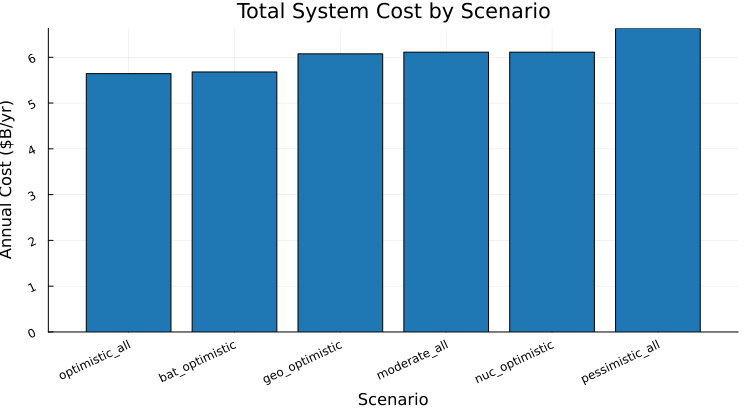

In [ ]:
# Total System cost for each scenario 
all_gen.Family = tech_family.(all_gen.Resource)
println("Technology families: ", sort(unique(all_gen.Family)))
sort!(all_cost, :Total_B)
println("=== Total System Cost (\$B/yr) ===")
show(all_cost[:, [:Scenario, :Total_B, :FixedGen_B, :FixedStor_B, :Variable_B, :NSE_B]], allrows=true)

bar(all_cost.Scenario, all_cost.Total_B,
    xlabel="Scenario", ylabel="Annual Cost (\$B/yr)",
    title="Total System Cost by Scenario",
    legend=false, color=palette(:tab10)[1], rotation=25,
    bottom_margin=8Plots.mm, size=(750,420))

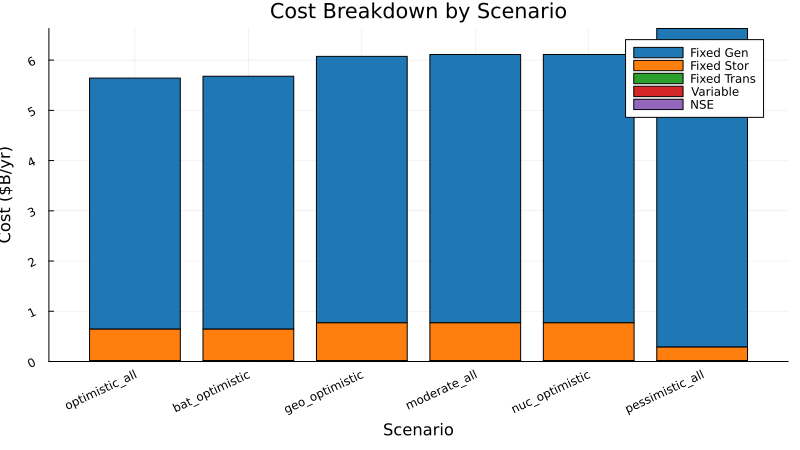

In [42]:
# Stacked total cost for each scenario 
cost_mat   = Matrix(all_cost[:, [:FixedGen_B, :FixedStor_B, :FixedTrans_B, :Variable_B, :NSE_B]])
cost_labels = ["Fixed Gen" "Fixed Stor" "Fixed Trans" "Variable" "NSE"]
scen_order  = all_cost.Scenario

groupedbar(cost_mat, bar_position=:stack,
    label=cost_labels,
    xticks=(1:length(scen_order), scen_order),
    xlabel="Scenario", ylabel="Cost (\$B/yr)",
    title="Cost Breakdown by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(800,450),
    palette=:tab10, legend=:topright)

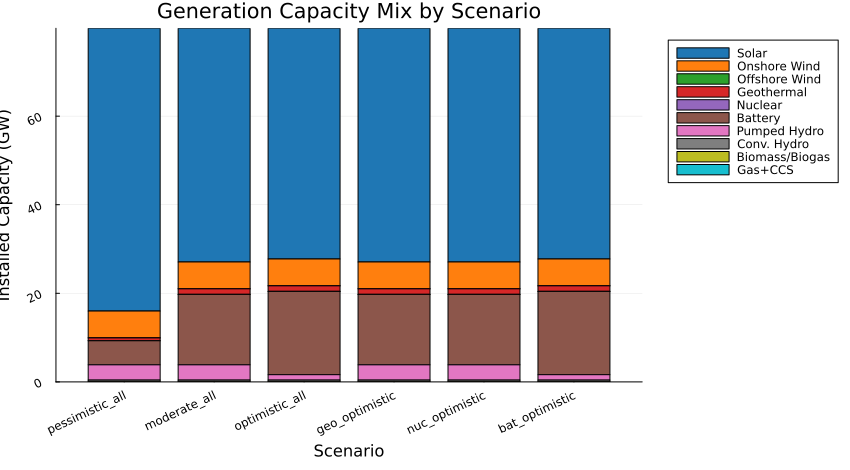

In [43]:
# Capacity mix by scenario 
cap_mix = combine(groupby(all_gen, [:Scenario, :Family]),
                  :Total_MW => (x -> sum(x)/1e3) => :GW)

families_ordered = ["Solar","Onshore Wind","Offshore Wind","Geothermal","Nuclear",
                    "Battery","Pumped Hydro","Conv. Hydro","Biomass/Biogas","Gas+CCS","Other"]
families_present = intersect(families_ordered, unique(cap_mix.Family))
scens = active_scenarios  # preserve input order

cap_mat = zeros(length(scens), length(families_present))
for (i,sc) in enumerate(scens), (j,fam) in enumerate(families_present)
    rows = cap_mix[(cap_mix.Scenario .== sc) .& (cap_mix.Family .== fam), :]
    cap_mat[i,j] = nrow(rows) > 0 ? rows.GW[1] : 0.0
end

groupedbar(cap_mat, bar_position=:stack,
    label=reshape(families_present, 1, :),
    xticks=(1:length(scens), scens),
    xlabel="Scenario", ylabel="Installed Capacity (GW)",
    title="Generation Capacity Mix by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(850,470),
    palette=:tab10, legend=:outertopright)

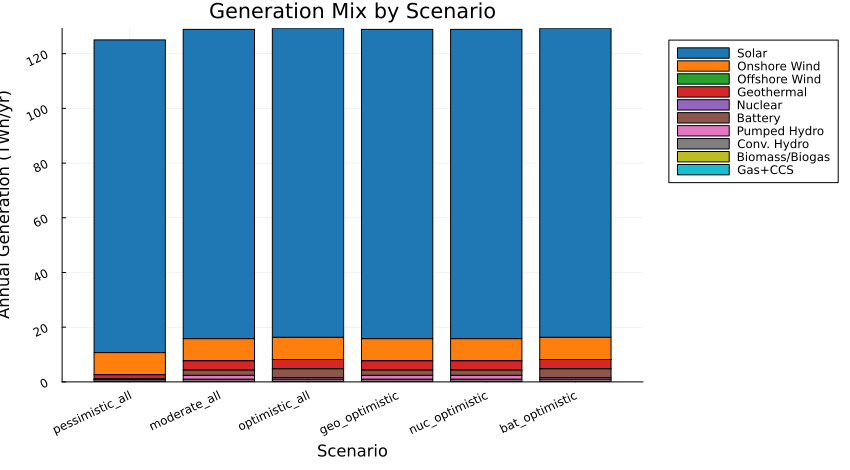

In [44]:
# Generation mix by scenario
gen_mix = combine(groupby(all_gen, [:Scenario, :Family]),
                  :GWh_yr => sum => :TWh)

gen_mat = zeros(length(scens), length(families_present))
for (i,sc) in enumerate(scens), (j,fam) in enumerate(families_present)
    rows = gen_mix[(gen_mix.Scenario .== sc) .& (gen_mix.Family .== fam), :]
    gen_mat[i,j] = nrow(rows) > 0 ? rows.TWh[1] / 1e3 : 0.0  # GWh → TWh
end

groupedbar(gen_mat, bar_position=:stack,
    label=reshape(families_present, 1, :),
    xticks=(1:length(scens), scens),
    xlabel="Scenario", ylabel="Annual Generation (TWh/yr)",
    title="Generation Mix by Scenario",
    rotation=25, bottom_margin=8Plots.mm, size=(850,470),
    palette=:tab10, legend=:outertopright)

In [45]:
# New capacity built by scenario
new_builds = all_gen[all_gen.New_MW .> 0.5, :]
new_agg = combine(groupby(new_builds, [:Scenario, :Family]),
                  :New_MW => (x -> sum(x)/1e3) => :New_GW)
sort!(new_agg, [:Scenario, :Family])
println("\nNew Capacity Built (GW)")
show(new_agg, allrows=true)


New Capacity Built (GW)
12×3 DataFrame
 Row │ Scenario         Family   New_GW   
     │ String           String   Float64  
─────┼────────────────────────────────────
   1 │ bat_optimistic   Battery  18.8228
   2 │ bat_optimistic   Solar    39.7703
   3 │ geo_optimistic   Battery  15.9043
   4 │ geo_optimistic   Solar    40.4483
   5 │ moderate_all     Battery  15.9043
   6 │ moderate_all     Solar    40.4483
   7 │ nuc_optimistic   Battery  15.9043
   8 │ nuc_optimistic   Solar    40.4483
   9 │ optimistic_all   Battery  18.8228
  10 │ optimistic_all   Solar    39.7703
  11 │ pessimistic_all  Battery   5.43299
  12 │ pessimistic_all  Solar    51.5278

# Full Model Run

This is the full model run, which requires some specificity in the following cells and prior cells to properly define the scenarios and datasets being ran

**Ensure proper dataset is selected in load data**

**Ensure output paths are changed if running multiple data set trials**


In [ ]:
# Reset active sets to full system 
ACTIVE_ZONES   = collect(1:6)  
ACTIVE_PERIODS = collect(1:16)

Z = ACTIVE_ZONES

gen_z = copy(generators)
gen_z.local_idx = 1:nrow(gen_z)
G = gen_z.local_idx

T_active = collect(1:length(T_full))
T        = 1:length(T_active)
sw       = sample_weight_full       

demand_zt   = demand_full            
fl_avail_zt = fl_avail                
var_zt      = var_cf                   

lines_z = lines
L       = L_all

NEW    = gen_z.local_idx[gen_z.New_Build .== 1]
OLD_0  = gen_z.local_idx[gen_z.New_Build .== 0]
RETIRE = gen_z.local_idx[gen_z.New_Build .== -1]
OLD    = vcat(OLD_0, RETIRE)

VRE      = gen_z.local_idx[gen_z.VRE     .== 1]
STOR     = gen_z.local_idx[gen_z.STOR    .>= 1]
STOR_OLD = intersect(STOR, OLD)
STOR_NEW = intersect(STOR, NEW)
THERM    = gen_z.local_idx[gen_z.THERM   .== 1]
MUSTRUN  = gen_z.local_idx[gen_z.MUSTRUN .== 1]
HYDRO    = gen_z.local_idx[gen_z.HYDRO   .== 1]

geo_ids = gen_z.local_idx[occursin.("geothermal", gen_z.Resource)]
nuc_ids = gen_z.local_idx[occursin.("nuclear",    gen_z.Resource)]
bat_ids = gen_z.local_idx[occursin.("battery",    gen_z.Resource)]

active_scenarios = collect(keys(cost_scenarios))

# if pilot ran prior
#pilot_gen   = copy(all_gen)
#pilot_stor  = copy(all_stor)
#pilot_trans = copy(all_trans)
#pilot_nse   = copy(all_nse)
#pilot_cost  = copy(all_cost)

all_gen   = DataFrame()
all_stor  = DataFrame()
all_trans = DataFrame()
all_nse   = DataFrame()
all_cost  = DataFrame()

0×0 DataFrame

In [ ]:
println("Full run: $(length(active_scenarios)) scenarios | $(length(G)) generators | $(length(T)) hours | $(length(Z)) zones")
println("Estimated runtime: 3-10 min/scenario with Gurobi, total time nearly 1.5 hours for 14 scenarios\n")

t0 = time()
for sc in active_scenarios
    mults = cost_scenarios[sc]
    r = build_and_solve(
        gen_z, mults, sc;
        T_idx=T, Z_set=Z, L_set=L, lines_df=lines_z,
        demand_mat=demand_zt, var_mat=var_zt, sw=sw,
        fl_avail_mat=fl_avail_zt,
        nse_df=nse,
        G_set=G, NEW_set=NEW, OLD_set=OLD, RETIRE_set=RETIRE, OLD_0_set=OLD_0,
        VRE_set=VRE, STOR_set=STOR, STOR_OLD_set=STOR_OLD, STOR_NEW_set=STOR_NEW,
        MUSTRUN_set=MUSTRUN, HYDRO_set=HYDRO,
        n_zones_total=n_zones,
        hours_per_subperiod=hours_per_week,
        include_flex_load=false
    )
    if r !== nothing
        append!(all_gen,   r.gen);   append!(all_stor,  r.stor)
        append!(all_trans, r.trans); append!(all_nse,   r.nse)
        append!(all_cost,  r.cost)

        # Save individual scenario to its own subfolder >>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> change to avoid overwriting some results
        sc_path = joinpath("results_full", "results_full_run_$(sc)")
        isdir(sc_path) || mkpath(sc_path)

        CSV.write(joinpath(sc_path, "generator_results.csv"),    r.gen)
        CSV.write(joinpath(sc_path, "storage_results.csv"),      r.stor)
        CSV.write(joinpath(sc_path, "transmission_results.csv"), r.trans)
        CSV.write(joinpath(sc_path, "nse_results.csv"),          r.nse)
        CSV.write(joinpath(sc_path, "cost_results.csv"),         r.cost)
        println("  Saved → results_full_run/results_full_run_$(sc)/")
    end
end

println("\nFull run complete in $(round((time()-t0)/3600, digits=2)) hours")
outpath_full = "results_full" #>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>>> Change for varying data sets to ensure results are not overwritten
CSV.write(joinpath(outpath_full, "generator_results_all.csv"),    all_gen)
CSV.write(joinpath(outpath_full, "storage_results_all.csv"),      all_stor)
CSV.write(joinpath(outpath_full, "transmission_results_all.csv"), all_trans)
CSV.write(joinpath(outpath_full, "nse_results_all.csv"),          all_nse)
CSV.write(joinpath(outpath_full, "cost_results_all.csv"),         all_cost)
println("Aggregate results saved to results_full_run/")
#println("Pilot results preserved in pilot_gen, pilot_cost, etc.")


Full run: 14 scenarios | 159 generators | 2688 hours | 6 zones
Estimated runtime: 30–60 min/scenario with HiGHS IPM, 3–10 min with Gurobi

Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
  ✓ geo_opt_nuc_pess | $13.634B/yr | 320.5s
  Saved → results_full_run/results_full_run_geo_opt_nuc_pess/
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
  ✓ moderate_all | $13.054B/yr | 215.6s
  Saved → results_full_run/results_full_run_moderate_all/
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
  ✓ nuc_optimistic | $13.578B/yr | 125.9s
  Saved → results_full_run/results_full_run_nuc_optimistic/
Set parameter Username
Set parameter LicenseID to value 2828482
Academic license - for non-commercial use only - expires 2027-05-28
  ✓ optimistic_all | $12.55

# Full Model Results 


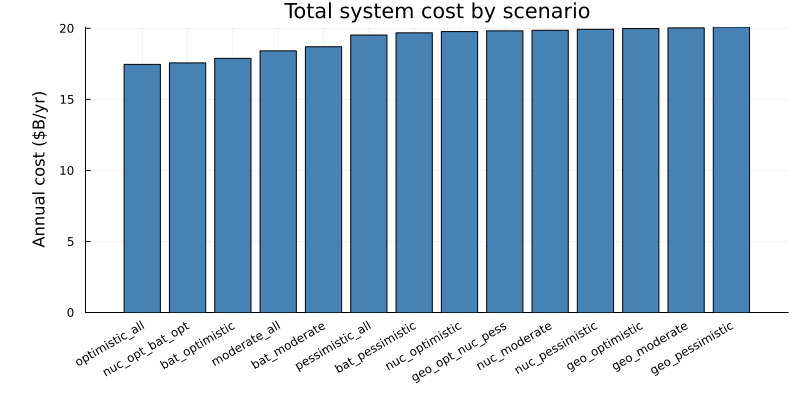

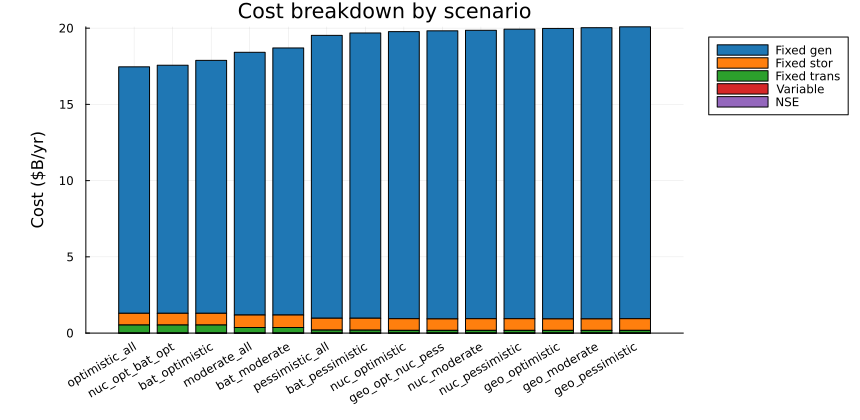

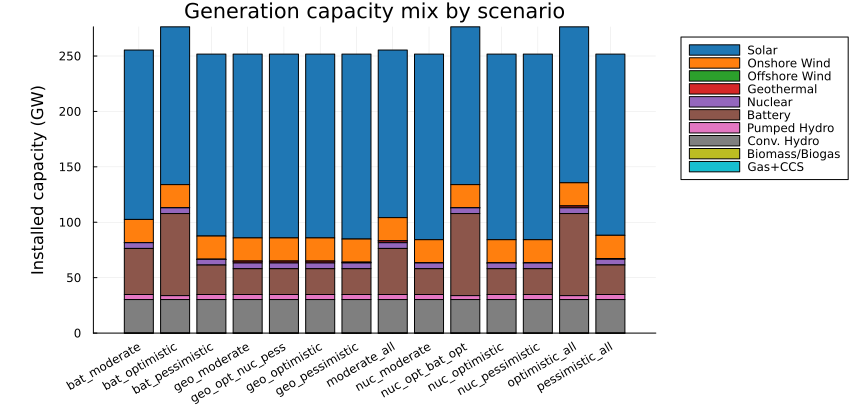

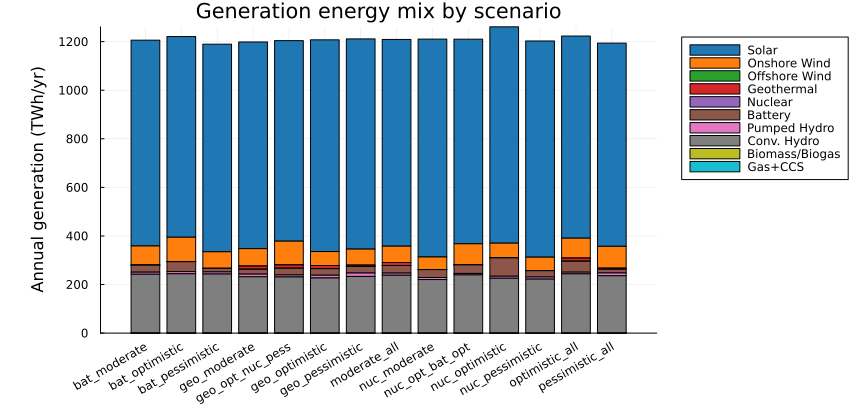

In [77]:
# Results visualisation part 2 
results_path = "results_full"  # redefine to visualize different runs of data sets

# Load
cost_df = DataFrame(CSV.File(joinpath(results_path, "cost_results_all.csv")))
gen_df  = DataFrame(CSV.File(joinpath(results_path, "generator_results_all.csv")))

gen_df.Family = tech_family.(gen_df.Resource)

# Shared ordering
scens = sort(unique(cost_df.Scenario))

families_ordered = ["Solar","Onshore Wind","Offshore Wind","Geothermal","Nuclear",
                    "Battery","Pumped Hydro","Conv. Hydro","Biomass/Biogas","Gas+CCS","Other"]
families_present = intersect(families_ordered, unique(gen_df.Family))

pal = palette(:tab10, length(families_present))

# Matrix stacking within results 
function stacked_matrix(df, val_col, scen_list, fam_list)
    mat = zeros(length(scen_list), length(fam_list))
    agg = combine(groupby(df, [:Scenario, :Family]), val_col => sum => :val)
    for (i,sc) in enumerate(scen_list), (j,fam) in enumerate(fam_list)
        rows = agg[(agg.Scenario .== sc) .& (agg.Family .== fam), :]
        mat[i,j] = nrow(rows) > 0 ? rows.val[1] : 0.0
    end
    mat
end

# 1. Total system cost 
cost_sorted = sort(cost_df, :Total_B)
p1 = bar(cost_sorted.Scenario, cost_sorted.Total_B,
    ylabel = "Annual cost (\$B/yr)",
    title  = "Total system cost by scenario",
    legend = false,
    color  = :steelblue,
    xrotation = 30,
    bottom_margin = 10Plots.mm,
    left_margin = 10Plots.mm,
    size = (800, 400))

# 2. Cost breakdown 
cost_labels = ["Fixed gen" "Fixed stor" "Fixed trans" "Variable" "NSE"]
cost_mat    = Matrix(cost_sorted[:, [:FixedGen_B, :FixedStor_B, :FixedTrans_B, :Variable_B, :NSE_B]])

p2 = groupedbar(cost_mat,
    bar_position  = :stack,
    label         = cost_labels,
    xticks        = (1:length(cost_sorted.Scenario), cost_sorted.Scenario),
    ylabel        = "Cost (\$B/yr)",
    title         = "Cost breakdown by scenario",
    xrotation     = 30,
    bottom_margin = 10Plots.mm,
    left_margin = 10Plots.mm,
    palette       = :tab10,
    legend        = :outertopright,
    size          = (860, 420))

# 3. Generation capacity mix
cap_mat = stacked_matrix(gen_df, :Total_MW, scens, families_present) ./ 1e3  # GW

p3 = groupedbar(cap_mat,
    bar_position  = :stack,
    label         = reshape(families_present, 1, :),
    xticks        = (1:length(scens), scens),
    ylabel        = "Installed capacity (GW)",
    title         = "Generation capacity mix by scenario",
    xrotation     = 30,
    bottom_margin = 10Plots.mm,
    left_margin = 10Plots.mm,
    palette       = pal,
    legend        = :outertopright,
    size          = (860, 420))

# 4. Generation energy mix
gen_mat = stacked_matrix(gen_df, :GWh_yr, scens, families_present) ./ 1e3  # TWh

p4 = groupedbar(gen_mat,
    bar_position  = :stack,
    label         = reshape(families_present, 1, :),
    xticks        = (1:length(scens), scens),
    ylabel        = "Annual generation (TWh/yr)",
    title         = "Generation energy mix by scenario",
    xrotation     = 30,
    bottom_margin = 10Plots.mm,
    left_margin = 10Plots.mm,
    palette       = pal,
    legend        = :outertopright,
    size          = (860, 420))

# Display graphs produced 
display(p1); display(p2); display(p3); display(p4)

In [41]:
cost_table = cost_sorted[:, [:Scenario, :Total_B]]
println(cost_table)


14×2 DataFrame
 Row │ Scenario          Total_B 
     │ String31          Float64 
─────┼───────────────────────────
   1 │ optimistic_all    12.552
   2 │ nuc_opt_bat_opt   12.6011
   3 │ bat_optimistic    12.6897
   4 │ nuc_optimistic    12.9653
   5 │ geo_optimistic    13.0047
   6 │ moderate_all      13.0538
   7 │ geo_moderate      13.0538
   8 │ nuc_moderate      13.0538
   9 │ bat_moderate      13.0538
  10 │ geo_opt_nuc_pess  13.0777
  11 │ geo_pessimistic   13.1077
  12 │ nuc_pessimistic   13.1268
  13 │ bat_pessimistic   13.5299
  14 │ pessimistic_all   13.6568


In [42]:
cost_breakdown_table = DataFrame(
    Scenario = cost_sorted.Scenario,
    FixedGen_B   = cost_sorted.FixedGen_B,
    FixedStor_B  = cost_sorted.FixedStor_B,
    FixedTrans_B = cost_sorted.FixedTrans_B,
    Variable_B   = cost_sorted.Variable_B,
    NSE_B        = cost_sorted.NSE_B
)

println(cost_breakdown_table)


14×6 DataFrame
 Row │ Scenario          FixedGen_B  FixedStor_B  FixedTrans_B  Variable_B  NSE_B   
     │ String31          Float64     Float64      Float64       Float64     Float64 
─────┼──────────────────────────────────────────────────────────────────────────────
   1 │ optimistic_all       11.9506     0.477708       0.12191  0.0017828       0.0
   2 │ nuc_opt_bat_opt      11.9997     0.477708       0.12191  0.0017828       0.0
   3 │ bat_optimistic       12.0883     0.477708       0.12191  0.0017828       0.0
   4 │ nuc_optimistic       12.2689     0.572781       0.12191  0.00167906      0.0
   5 │ geo_optimistic       12.3084     0.572781       0.12191  0.00167906      0.0
   6 │ moderate_all         12.3575     0.572781       0.12191  0.00167906      0.0
   7 │ geo_moderate         12.3575     0.572781       0.12191  0.00167906      0.0
   8 │ nuc_moderate         12.3575     0.572781       0.12191  0.00167906      0.0
   9 │ bat_moderate         12.3575     0.572781       0.1

In [43]:
cap_table = DataFrame(cap_mat, Symbol.(families_present))
cap_table.Scenario = scens
select!(cap_table, [:Scenario, Symbol.(families_present)...])

println(cap_table)


14×11 DataFrame
 Row │ Scenario          Solar    Onshore Wind  Offshore Wind  Geothermal  Nuclear  Battery   Pumped Hydro  Conv. Hydro  Biomass/Biogas  Gas+CCS 
     │ String31          Float64  Float64       Float64        Float64     Float64  Float64   Float64       Float64      Float64         Float64 
─────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ bat_moderate      106.657       20.9628            0.0     1.65044  5.16599  15.408         4.54875      30.2168         0.04296      0.0
   2 │ bat_optimistic    106.924       20.9628            0.0     1.65044  5.16599  19.1237        3.21313      28.0733         0.04296      0.0
   3 │ bat_pessimistic   115.393       20.9628            0.0     1.65044  5.16599   6.67152       4.54875      30.2168         0.04296      0.0
   4 │ geo_moderate      106.657       20.9628            0.0     1.65044  5.16599  15.408         4.54875     

In [44]:
gen_table = DataFrame(gen_mat, Symbol.(families_present))
gen_table.Scenario = scens
select!(gen_table, [:Scenario, Symbol.(families_present)...])

println(gen_table)


14×11 DataFrame
 Row │ Scenario          Solar    Onshore Wind  Offshore Wind  Geothermal  Nuclear    Battery   Pumped Hydro  Conv. Hydro  Biomass/Biogas  Gas+CCS 
     │ String31          Float64  Float64       Float64        Float64     Float64    Float64   Float64       Float64      Float64         Float64 
─────┼─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
   1 │ bat_moderate      594.674       92.9762            0.0    12.8572   0.109088   14.0766        8.3551       206.368        0.157471      0.0
   2 │ bat_optimistic    598.831       96.2386            0.0    12.9097   0.119973   15.8398        6.03701      198.432        0.157508      0.0
   3 │ bat_pessimistic   604.529       89.9917            0.0    12.6874   0.0695569  11.4301        8.1244       199.151        0.156461      0.0
   4 │ geo_moderate      594.674       92.9762            0.0    12.8572   0.109088   14.0766      